# 🧼 Checkpoint 8 — Focus Preprocessing (Nettoyage & Mise à l'Échelle)

## Module Data Science — Preprocessing

> **Prérequis :** cours *Nettoyage des Données & Mise à l'Échelle* (`05-...md`).

Notebook **corrigé** du checkpoint 8. Quatre parties :
- **A.** Nettoyage de données réelles (`fiche_employes.csv`)
- **B.** Feature Scaling — comparaison des 4 échelles (`demandes_credit.csv`)
- **C.** Pipeline de preprocessing anti-fuite + modèle
- **D.** Prédictions sur des données de test (échantillon + nouveau client)

> 💡 Les jeux de données sont ceux du repo. Le résolveur de chemin ci-dessous trouve les CSV
> quel que soit le dossier d'exécution (repo local ou upload Colab).

In [1]:
!pip install scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)

def trouver(nom):
    """Cherche un CSV dans les emplacements probables du repo (ou dossier courant)."""
    candidats = [nom,
                 f'../../03-data-science/TP/{nom}',
                 f'../TP/{nom}',
                 f'04-machine-learning/TP/{nom}',
                 f'03-data-science/TP/{nom}']
    for c in candidats:
        if Path(c).exists():
            return c
    raise FileNotFoundError(f"{nom} introuvable — uploadez-le à côté du notebook.")

print('Environnement prêt ✅')


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Environnement prêt ✅


---
# PARTIE A — Nettoyer des données réelles

`fiche_employes.csv` contient des défauts typiques du terrain : noms de colonnes incohérents
(typo `Fist Name`), adresses multilignes, téléphones variés, intitulés de poste en tuple-texte
`"('Chef de projet finance',)"`, villes en casses différentes, valeurs manquantes.

## A.1 — Charger & diagnostiquer la qualité

In [2]:
df = pd.read_csv(trouver('fiche_employes.csv'))
print('Dimensions :', df.shape)
print('\nColonnes brutes :', list(df.columns))
print('\nValeurs manquantes par colonne :')
print(df.isna().sum())
print('\nDoublons exacts :', df.duplicated().sum())
df.head(3)

Dimensions : (5100, 13)

Colonnes brutes : ['Age', 'Email', 'Phone', 'Address', 'Salary', 'Join_Date', 'Employment_Status', 'Gender', 'Department', 'Ville', 'Djob_tilte', 'Fist Name', 'Last Name']

Valeurs manquantes par colonne :
Age                   0
Email                51
Phone                 0
Address               0
Salary                0
Join_Date             0
Employment_Status     0
Gender                0
Department            0
Ville                 0
Djob_tilte            0
Fist Name             0
Last Name             0
dtype: int64

Doublons exacts : 100


,Age,Email,Phone,Address,Salary,Join_Date,Employment_Status,Gender,Department,Ville,Djob_tilte,Fist Name,Last Name
0,63,laurentnicole@example.com,+33 2 47 21 81 96,rue Rey\n64616 Saint Michelle,51451,2023-07-27,Part-Time,F,Finance,Gagnoa,"('Chef de projet finance',)",Vasseur,Pons
1,70,suzanne02@example.net,03 23 42 35 11,chemin Josette Aubry\n06747 RegnierBourg,64565,2023-03-22,CDI,F,IT,Yamoussoukro,"('Spécialiste en cybersécurité',)",Chevalier,Courtois
2,21,veronique95@example.net,+33 4 89 10 34 13,"67, chemin Monnier\n26686 Boutin",37198,2020-08-09,Part-Time,M,Marketing,Daloa,"('Chef de produit',)",Thibaut,Bousquet


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                5100 non-null   int64
 1   Email              5049 non-null   str  
 2   Phone              5100 non-null   str  
 3   Address            5100 non-null   str  
 4   Salary             5100 non-null   int64
 5   Join_Date          5100 non-null   str  
 6   Employment_Status  5100 non-null   str  
 7   Gender             5100 non-null   str  
 8   Department         5100 non-null   str  
 9   Ville              5100 non-null   str  
 10  Djob_tilte         5100 non-null   str  
 11  Fist Name          5100 non-null   str  
 12  Last Name          5100 non-null   str  
dtypes: int64(2), str(11)
memory usage: 518.1 KB


## A.2 — Nettoyage complet

On travaille sur une **copie** (données brutes préservées), dans l'ordre méthodique :
colonnes → types → texte → inexactitudes → manquants → doublons → outliers.

In [4]:
df_clean = df.copy()   # ✅ ne jamais toucher à l'original

# 1. Noms de colonnes : minuscules, sans espaces, corriger les typos
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')
df_clean = df_clean.rename(columns={'fist_name': 'first_name',
                                    'djob_tilte': 'job_title'})

# 2. Types corrects
df_clean['salary'] = pd.to_numeric(df_clean['salary'], errors='coerce')
df_clean['join_date'] = pd.to_datetime(df_clean['join_date'], errors='coerce')

# 3. Texte : ville normalisée + poste extrait du tuple-texte
df_clean['ville'] = df_clean['ville'].str.strip().str.lower()
df_clean['job_title'] = df_clean['job_title'].str.extract(r"'([^']+)'")

# 4. Inexactitudes : âge hors bornes plausibles -> manquant
df_clean.loc[(df_clean['age'] > 100) | (df_clean['age'] < 16), 'age'] = np.nan

# 5. Manquants : médiane (numérique), mode (catégoriel)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median()).astype(int)
df_clean['salary'] = df_clean['salary'].fillna(df_clean['salary'].median())
for col in ['department', 'ville', 'gender', 'employment_status']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 6. Dédupliquer sur l'email (APRÈS standardisation)
df_clean['email'] = df_clean['email'].str.strip().str.lower()
avant = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['email'], keep='first')
print(f'Doublons email supprimés : {avant - len(df_clean)}')

Doublons email supprimés : 188


## A.3 — Détecter et traiter les outliers de `salary` (méthode IQR)

Un salaire élevé est **plausible** (cadre dirigeant) → on **cappe** plutôt que de supprimer.

Bornes IQR : [-44,507 ; 214,609]  —  outliers détectés : 20
Salaire max : 494,263 (brut)  ->  214,609 (après capping)


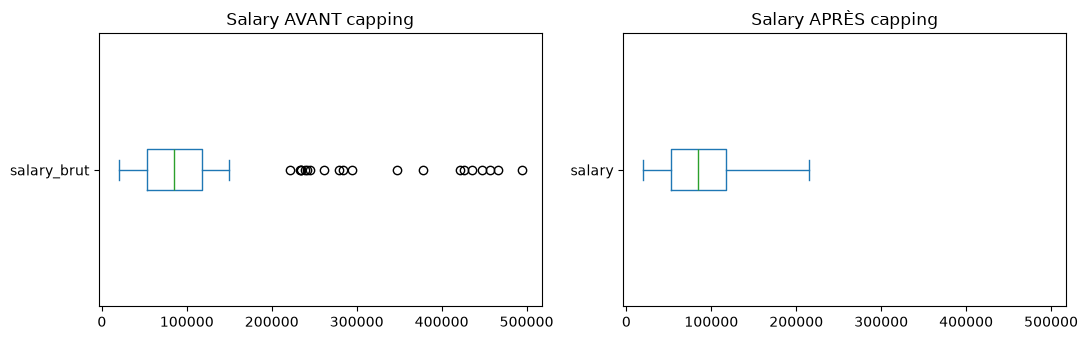

In [5]:
# Snapshot du salaire AVANT capping — fait UNE seule fois, donc la cellule
# reste correcte même si on la ré-exécute (sinon 'avant' = déjà cappé).
if 'salary_brut' not in df_clean.columns:
    df_clean['salary_brut'] = df_clean['salary']

# Bornes IQR calculées sur le BRUT
Q1, Q3 = df_clean['salary_brut'].quantile([0.25, 0.75])
IQR = Q3 - Q1
bas, haut = Q1 - 1.5*IQR, Q3 + 1.5*IQR
n_out = int(((df_clean['salary_brut'] < bas) | (df_clean['salary_brut'] > haut)).sum())
print(f'Bornes IQR : [{bas:,.0f} ; {haut:,.0f}]  —  outliers détectés : {n_out}')
print(f"Salaire max : {df_clean['salary_brut'].max():,.0f} (brut)  ->  {haut:,.0f} (après capping)")

# Capping à partir du BRUT (idempotent)
df_clean['salary'] = df_clean['salary_brut'].clip(bas, haut)

# Comparaison AVANT (brut) vs APRÈS (cappé) — mêmes bornes d'axe pour bien voir l'effet
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True)
df_clean['salary_brut'].plot.box(ax=axes[0], vert=False); axes[0].set_title('Salary AVANT capping')
df_clean['salary'].plot.box(ax=axes[1], vert=False); axes[1].set_title('Salary APRÈS capping')
plt.tight_layout(); plt.show()

## A.4 — Vérification finale du nettoyage

In [6]:
print('Dimensions finales :', df_clean.shape)
print('\nManquants restants (colonnes clés) :')
print(df_clean[['age','salary','department','ville','gender','employment_status']].isna().sum())
print('\nExemples de postes nettoyés :', df_clean['job_title'].dropna().unique()[:4])
df_clean.head(3)

Dimensions finales : (4912, 14)

Manquants restants (colonnes clés) :
age                  0
salary               0
department           0
ville                0
gender               0
employment_status    0
dtype: int64

Exemples de postes nettoyés : <StringArray>
[            'Chef de projet finance',       'Spécialiste en cybersécurité',
                    'Chef de produit', 'Responsable des risques financiers']
Length: 4, dtype: str


,age,email,phone,address,salary,join_date,employment_status,gender,department,ville,job_title,first_name,last_name,salary_brut
0,63,laurentnicole@example.com,+33 2 47 21 81 96,rue Rey\n64616 Saint Michelle,51451.0,2023-07-27,Part-Time,F,Finance,gagnoa,Chef de projet finance,Vasseur,Pons,51451
1,70,suzanne02@example.net,03 23 42 35 11,chemin Josette Aubry\n06747 RegnierBourg,64565.0,2023-03-22,CDI,F,IT,yamoussoukro,Spécialiste en cybersécurité,Chevalier,Courtois,64565
2,21,veronique95@example.net,+33 4 89 10 34 13,"67, chemin Monnier\n26686 Boutin",37198.0,2020-08-09,Part-Time,M,Marketing,daloa,Chef de produit,Thibaut,Bousquet,37198


---
# PARTIE B — Feature Scaling : comparer les 4 échelles

Sur `demandes_credit.csv`, on compare **MaxAbs**, **MinMax**, **Standard** et **Robust**
sur des variables aux amplitudes très différentes (`age` vs `revenu_mensuel`).

In [7]:
credit = pd.read_csv(trouver('demandes_credit.csv'))
cols = ['age', 'revenu_mensuel', 'montant_demande']
X = credit[cols].dropna()

print('AVANT tout scaling — noter les écarts d\'amplitude :')
X.describe().loc[['min', 'max', 'mean', 'std']].round(1)

AVANT tout scaling — noter les écarts d'amplitude :


,age,revenu_mensuel,montant_demande
min,21.0,80000.0,420000.0
max,64.0,1482000.0,56460000.0
mean,42.4,360594.0,8156401.4
std,12.6,208675.4,6421577.9


In [8]:
from sklearn.preprocessing import (MaxAbsScaler, MinMaxScaler,
                                   StandardScaler, RobustScaler)

scalers = {'MaxAbs': MaxAbsScaler(), 'MinMax': MinMaxScaler(),
           'Standard': StandardScaler(), 'Robust': RobustScaler()}

for nom, sc in scalers.items():
    Xs = pd.DataFrame(sc.fit_transform(X), columns=cols)
    stats = Xs.describe().loc[['min', 'max', 'mean', 'std']].round(3)
    print(f'\n=== {nom} ===')
    print(stats)

print('\n👉 MinMax -> [0,1] exact | Standard -> moyenne≈0, std≈1 | Robust -> médiane centrée (résiste aux outliers)')


=== MaxAbs ===
        age  revenu_mensuel  montant_demande
min   0.328           0.054            0.007
max   1.000           1.000            1.000
mean  0.662           0.243            0.144
std   0.197           0.141            0.114

=== MinMax ===
        age  revenu_mensuel  montant_demande
min   0.000           0.000            0.000
max   1.000           1.000            1.000
mean  0.497           0.200            0.138
std   0.293           0.149            0.115

=== Standard ===
        age  revenu_mensuel  montant_demande
min  -1.698          -1.345           -1.205
max   1.716           5.374            7.523
mean  0.000          -0.000            0.000
std   1.000           1.000            1.000

=== Robust ===
        age  revenu_mensuel  montant_demande
min  -1.000          -0.888           -0.781
max   1.048           4.343            6.622
mean  0.019           0.159            0.241
std   0.600           0.779            0.848

👉 MinMax -> [0,1] exact | Standar

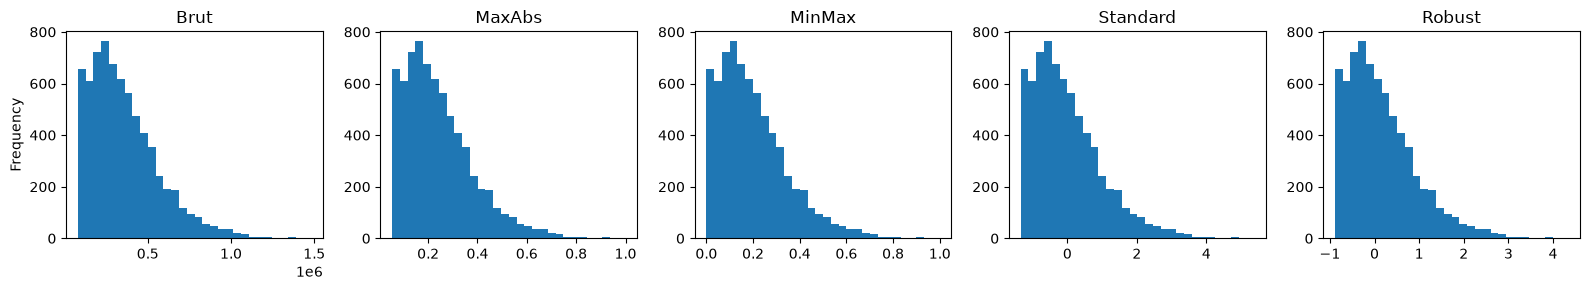

La FORME est préservée ; seule l'ÉCHELLE change.


In [9]:
# Visualiser l'effet sur 'revenu_mensuel'
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=False)
X['revenu_mensuel'].plot.hist(ax=axes[0], bins=30); axes[0].set_title('Brut')
for ax, (nom, sc) in zip(axes[1:], scalers.items()):
    vals = sc.fit_transform(X)[:, 1]   # colonne revenu_mensuel
    ax.hist(vals, bins=30); ax.set_title(nom)
plt.tight_layout(); plt.show()

print('La FORME est préservée ; seule l\'ÉCHELLE change.')

### 🔬 Faut-il scaler ici ?

| Algorithme | Scaling ? | Pourquoi |
|------------|-----------|----------|
| **Random Forest** | ❌ Non | Découpe par seuils, insensible à l'échelle |
| **KNN / SVM / régression** | ✅ Oui | Basés sur distances / gradient → le revenu écraserait l'âge sans scaling |

---
# PARTIE C — Pipeline de preprocessing complet (anti-fuite)

On assemble **imputation + scaling + encodage + modèle** dans un `Pipeline` avec `ColumnTransformer`.
Tout est `fit` **sur le train uniquement** → aucune fuite de données possible.

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

X = credit.drop(columns=['credit_accorde'])
y = credit['credit_accorde']

# 1. Split stratifié AVANT toute transformation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train :', X_train.shape, '| Test :', X_test.shape)

Train : (5600, 11) | Test : (1400, 11)


In [11]:
# 2. Colonnes par type (détection automatique)
num = X.select_dtypes('number').columns.tolist()
cat = X.select_dtypes('object').columns.tolist()
print('Numériques :', num)
print('Catégorielles :', cat)

pipe_num = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler())])
pipe_cat = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('onehot',  OneHotEncoder(handle_unknown='ignore'))])

prep = ColumnTransformer([('num', pipe_num, num),
                          ('cat', pipe_cat, cat)])

# 3. Pipeline complet : preprocessing + modèle
model = Pipeline([('prep', prep),
                  ('clf',  LogisticRegression(max_iter=1000))])

Numériques : ['age', 'revenu_mensuel', 'anciennete_emploi', 'montant_demande', 'duree_pret_mois', 'nb_credits_actuels', 'apport_personnel', 'nb_personnes_charge']
Catégorielles : ['type_contrat', 'historique_credit', 'situation_familiale']


In [12]:
# 4. Entraîner sur le TRAIN, évaluer sur le TEST
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print()
print(classification_report(y_test, y_pred))

Accuracy : 0.904
F1       : 0.920

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       560
           1       0.91      0.93      0.92       840

    accuracy                           0.90      1400
   macro avg       0.90      0.90      0.90      1400
weighted avg       0.90      0.90      0.90      1400



```text
🔍 Analyse détaillée pour le risque de crédit
• Une excellente performance globale : Avec 90,4 % d'accuracy, votre modèle se trompe dans moins de 10 % des cas au total. C'est un score très solide pour du score de crédit.
• La détection des clients à risque (Classe 0) :
	• Rappel de 87 % : Le modèle réussit à identifier 87 % des clients qui vont réellement faire défaut. C'est le point le plus critique pour la banque afin d'éviter les pertes financières. Il y a cependant 13 % de clients à risque qui passent entre les mailles du filet (faux négatifs).
	• Précision de 89 % : Lorsque le modèle refuse un crédit en classant un client dans la catégorie "à risque", il a raison dans 89 % des cas. 11 % des clients refusés étaient pourtant de bons payeurs (manque à gagner pour la banque).
• La détection des clients fiables (Classe 1) :
	• Rappel de 93 % : Le modèle capte la très grande majorité des bons clients, ce qui permet de maximiser le volume de crédits accordés en toute sécurité.
💡 Recommandation pour votre business
Le F1-score de 0,88 sur la classe à risque (0) montre que le modèle équilibre bien la rigueur et la rentabilité.
Si votre banque souhaite être plus prudente face au risque de faillite, vous devriez ajuster le seuil de décision du modèle pour augmenter le Rappel de la classe 0, quitte à baisser légèrement sa précision. Il vaut souvent mieux refuser quelques bons clients supplémentaires (perte d'opportunité) que d'accorder un crédit à un client qui ne remboursera jamais (perte nette du capital).

In [13]:
# 5. Preuve d'anti-fuite : le scaler n'a appris QUE sur le train
scaler_ajuste = model.named_steps['prep'].named_transformers_['num'].named_steps['scaler']
moy_pipeline = scaler_ajuste.mean_[num.index('revenu_mensuel')]
moy_train    = X_train['revenu_mensuel'].mean()
moy_all      = X['revenu_mensuel'].mean()
print(f"Moyenne apprise par le pipeline : {moy_pipeline:,.1f}")
print(f"Moyenne du TRAIN seul           : {moy_train:,.1f}   <- doit correspondre")
print(f"Moyenne de TOUT le dataset      : {moy_all:,.1f}   <- ne correspond PAS (sinon = fuite)")

Moyenne apprise par le pipeline : 360,161.6
Moyenne du TRAIN seul           : 360,161.6   <- doit correspondre
Moyenne de TOUT le dataset      : 360,594.0   <- ne correspond PAS (sinon = fuite)


In [14]:
# 6. Bonus : validation croisée sur le train (5 folds)
cv = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print(f'F1 en validation croisée : {cv.mean():.3f} ± {cv.std():.3f}')
print('Écart-type faible = modèle stable ✅')

F1 en validation croisée : 0.909 ± 0.008
Écart-type faible = modèle stable ✅


---
# PARTIE D — Prédire sur des données de test

Le `Pipeline` entraîné en **PARTIE C** sait `predict` directement sur des données brutes (non transformées) :
il applique automatiquement `impute → scale/encode → modèle`. On l'utilise ici sur :
1. un **échantillon du test set** (`X_test`), pour comparer prédiction vs réalité ;
2. un **nouveau client fictif**, comme en production.

In [15]:
# 1. Prédire sur quelques lignes du test set (jamais vues pendant l'entraînement)
echantillon = X_test.sample(8, random_state=42)

y_pred_ech = model.predict(echantillon)
proba_ech = model.predict_proba(echantillon)[:, 1]   # proba d'appartenir à la classe 1 (crédit accordé)

resultats = echantillon.copy()
resultats['credit_accorde_reel'] = y_test.loc[echantillon.index]
resultats['credit_accorde_predit'] = y_pred_ech
resultats['proba_accord'] = proba_ech.round(3)
resultats['correct'] = resultats['credit_accorde_reel'] == resultats['credit_accorde_predit']

resultats[['age', 'revenu_mensuel', 'montant_demande',
           'credit_accorde_reel', 'credit_accorde_predit', 'proba_accord', 'correct']]

,age,revenu_mensuel,montant_demande,credit_accorde_reel,credit_accorde_predit,proba_accord,correct
2686,64,307000,2760000,0,0,0.416,True
6979,39,450000,5780000,1,1,0.986,True
5932,60,244000,6130000,0,0,0.010,True
6646,62,306000,4880000,1,1,0.977,True
950,29,145000,5270000,0,1,0.605,False
2362,61,174000,2790000,1,1,0.546,True
4472,50,115000,2330000,0,0,0.060,True
5351,55,220000,3020000,0,0,0.269,True


In [16]:
# 2. Score sur cet échantillon (à titre indicatif — 8 lignes seulement)
n_corrects = resultats['correct'].sum()
print(f"Prédictions correctes sur l'échantillon : {n_corrects}/{len(resultats)}")
print("\n👉 Rappel : la vraie évaluation du modèle se fait sur l'ENSEMBLE du test set (PARTIE C, accuracy/F1), "
      "pas sur un petit échantillon comme ici.")

Prédictions correctes sur l'échantillon : 7/8

👉 Rappel : la vraie évaluation du modèle se fait sur l'ENSEMBLE du test set (PARTIE C, accuracy/F1), pas sur un petit échantillon comme ici.


In [17]:
# 3. Prédire sur un tout NOUVEAU client (cas d'usage réel : pas de label connu)
nouveau_client = pd.DataFrame([{
    'age': 34,
    'revenu_mensuel': 320000,
    'anciennete_emploi': 5.0,
    'type_contrat': 'CDI',
    'montant_demande': 1500000,
    'duree_pret_mois': 36,
    'nb_credits_actuels': 1,
    'historique_credit': 'bon',
    'apport_personnel': 150000.0,
    'situation_familiale': 'marie',
    'nb_personnes_charge': 2,
}])

prediction = model.predict(nouveau_client)[0]
proba = model.predict_proba(nouveau_client)[0, 1]

statut = 'Accordé ✅' if prediction == 1 else 'Refusé ❌'
print(f'Décision du modèle : {statut}')
print(f"Probabilité d'accord : {proba:.1%}")

Décision du modèle : Accordé ✅
Probabilité d'accord : 63.6%


---
# ✅ Synthèse du checkpoint

| Partie | Compétence validée |
|--------|--------------------|
| **A** | Diagnostiquer + nettoyer des données réelles (types, texte, manquants, doublons, outliers) |
| **B** | Choisir et comparer les mises à l'échelle ; savoir quand scaler |
| **C** | Pipeline + ColumnTransformer anti-fuite, prêt pour la production |
| **D** | Utiliser le pipeline entraîné pour prédire sur du test/de nouvelles données |

> 🔑 **La règle d'or** : `fit` sur le **train uniquement**. Le Pipeline garantit l'anti-fuite par construction.

### 🚀 Pour aller plus loin
- Remplacez `LogisticRegression` par un `RandomForestClassifier` (retirez le scaler : inutile pour un arbre).
- Ajoutez un `GridSearchCV` sur le pipeline pour régler les hyperparamètres (cours 03).
- Testez `KNNImputer` au lieu de `SimpleImputer` pour l'imputation numérique.

---
*📘 Module Data Science — Checkpoint 8 : Focus Preprocessing | Bootcamp Data Science*